### ============================================================
## ABHIJEET S | CB.AI.P2DSC25003 | COMPUTATIONAL MATHEMATICS END SEM PROJECT
## MM & IRLS for Logistic Reduced Rank Regression
### ============================================================

# Introduction

### This project implements and explains the methodology introduced in the paper:

### “A New Algorithm and Visualization Framework for Logistic Reduced Rank Regression (LRRR)”
### Mark de Rooij (2024, Behaviormetrika)

### The goal of Logistic Reduced Rank Regression (LRRR) is to model multiple binary outcomes simultaneously using a reduced-dimensional latent structure:

## 𝐴=𝐵𝑉⊤

### where:

###  -> B is a predictor loading matrix
###  -> V is a response loading matrix

###  -> The product 𝐵𝑉⊤ has low rank, enabling dimensionality reduction.

###  This structure allows us to:

###  ->Capture hidden latent factors linking predictors to multiple binary outcomes

###  ->Perform joint modeling instead of separate logistic regressions

###  ->Produce visualizations (triplots) to interpret predictors, responses, and individuals in            latent space.

## This project:

### Re-implements the MM (Majorization–Minimization) algorithm proposed in the paper.

### Compares MM with the classical IRLS (Iteratively Reweighted Least Squares) method.

### Applies both algorithms on two real datasets:

### -> DRUG Consumption Dataset (UCI Repository)

### -> Student Performance Dataset (UCI) — converted to binary outcomes (pass/fail).

## Demonstrates:

### -> Rank-2 latent space factorization

### -> Logistic deviance comparisons

### -> Predictor–response relationships

### -> Visualization using Type I, Type D, and Hybrid Triplots

## The paper compares:

## IRLS algorithm (Yee & Hastie)

### -> Alternating updates for 𝐵 and 𝑉

### -> Requires computing working weights 𝑊 of size 𝑁×𝑅

### -> Requires heavy matrix inversions each iteration

### -> Often converges in few iterations but each step is slow

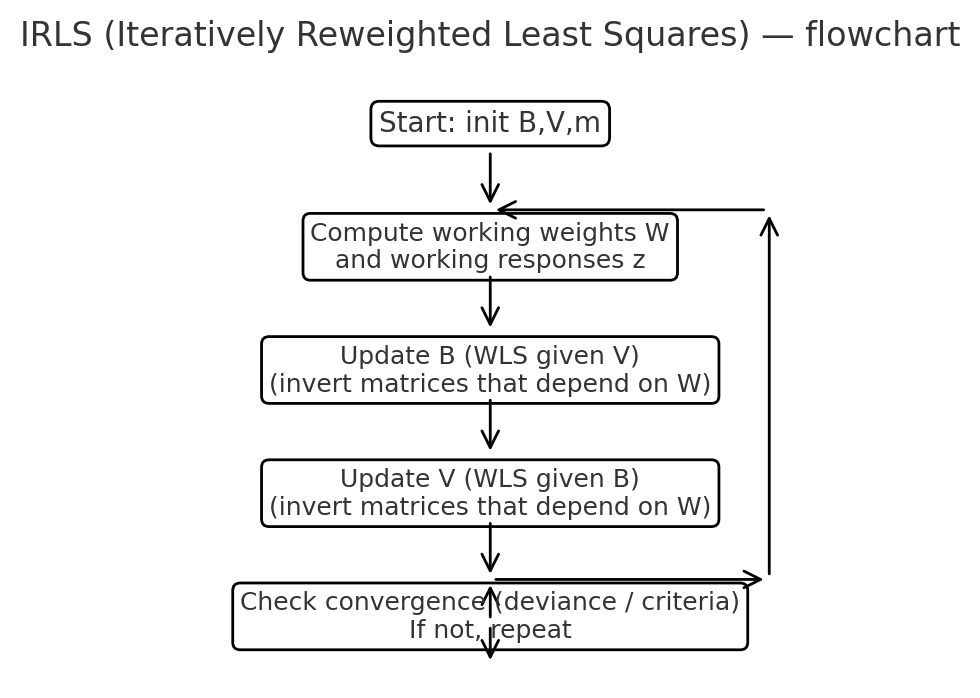

## MM algorithm (Majorization–Minimization, De Rooij)

### -> Uses quadratic upper-bound: 𝐿(𝜂) ≤ 1/8 (𝜂−𝑧)^2 + 𝑐 ​ 

### -> Reduces LRRR to least squares

### -> Each iteration becomes Constrained PCA

### -> Computed efficiently with Generalized SVD

### -> Monotone, stable, and often 10–100× faster

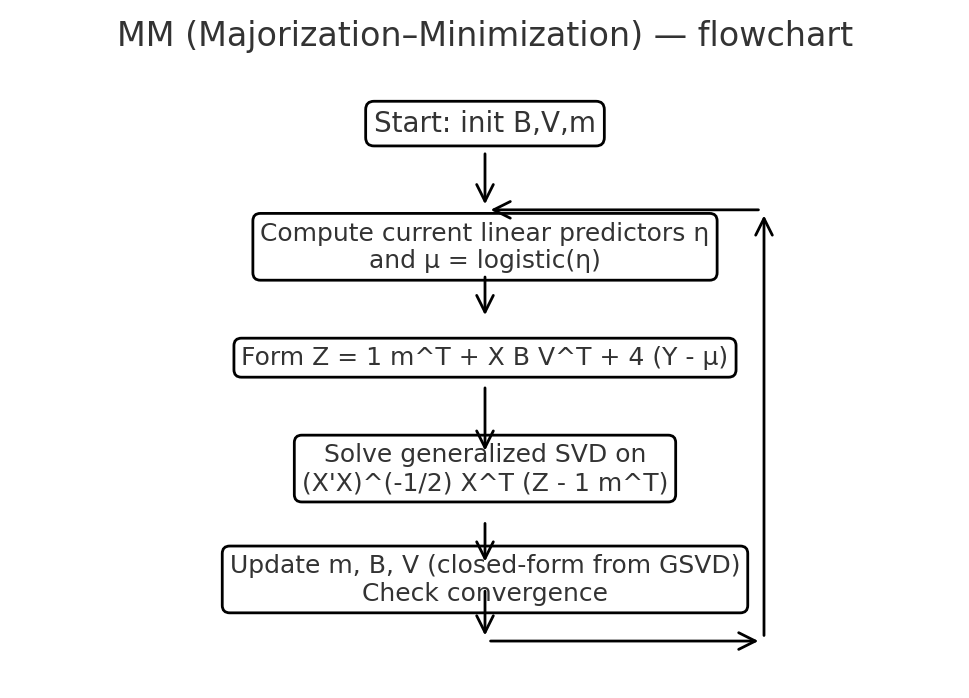

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from numpy.linalg import svd
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import time

# The sigmoid function maps linear predictors to probabilities, forming the logistic link.
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))
    
# Computes (X⊤X)^−1/2 essential for the generalized SVD step in the MM algorithm
def compute_inv_sqrt_sym(A):
    """Inverse square-root of symmetric PD matrix A.
       If A is P×P, returns (A)^{-1/2} (P×P)."""
    vals, vecs = eigh(A)
    vals[vals < 1e-12] = 1e-12
    return vecs @ np.diag(1.0 / np.sqrt(vals)) @ vecs.T

def impute_numeric(df):
    imp = SimpleImputer(strategy="median")
    return pd.DataFrame(imp.fit_transform(df), columns=df.columns)

def impute_categorical(df):
    imp = SimpleImputer(strategy="most_frequent")
    return pd.DataFrame(imp.fit_transform(df), columns=df.columns)


# Dataset loading & Preprocessing 


In [4]:
# STUDENT PERFORMANCE DATASET

# OUTPUT: X (N×P numpy), Y (N×R numpy), predictor_names, response_names
def load_student_data():
    # Load the two student files and concatenate
    df_math = pd.read_csv("student-mat.csv", sep=";")
    df_por  = pd.read_csv("student-por.csv",  sep=";")
    df = pd.concat([df_math, df_por], axis=0).reset_index(drop=True)
    print(f"Loaded combined student data: {df.shape[0]} rows")

    # Predictors: numeric + categorical (one-hot)
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

    X_num = impute_numeric(df[num_cols])
    X_cat = impute_categorical(df[cat_cols])

    X_df = pd.get_dummies(pd.concat([X_num, X_cat], axis=1), drop_first=True)
    predictor_names = list(X_df.columns)

    # Responses (multivariate binary)
    # pass_math: from math dataset (1 if G3 >= 10)
    df_math = df_math.copy()
    df_math['pass_math'] = (df_math['G3'] >= 10).astype(int)
    # pass_por: from por dataset
    df_por  = df_por.copy()
    df_por['pass_por'] = (df_por['G3'] >= 10).astype(int)

    # Create aligned vectors of length N:
    # for rows from math -> pass_math has value, pass_por = 0
    # for rows from por  -> pass_por has value, pass_math = 0
    pass_math = pd.concat([df_math['pass_math'], pd.Series([0]*len(df_por))], ignore_index=True)
    pass_por  = pd.concat([pd.Series([0]*len(df_math)), df_por['pass_por']], ignore_index=True)

    # high_absence computed on combined df
    high_absence = (df['absences'] > 5).astype(int)

    Y_df = pd.DataFrame({
        "pass_math": pass_math,
        "pass_por":  pass_por,
        "high_absence": high_absence
    })

    response_names = list(Y_df.columns)

    # Return numpy arrays
    X = X_df.values    # shape: (N, P)
    Y = Y_df.values    # shape: (N, R)

    print(f"Predictors (P) = {X.shape[1]}, Responses (R) = {Y.shape[1]}")
    return X, Y, predictor_names, response_names

# DRUG DATA

def load_drug_data():
    print("Loading UCI Drug Consumption dataset...")

    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00373/drug_consumption.data"

    cols = ["ID","Age","Gender","Education","Country","Ethnicity",
            "N","E","O","A","C","Imp","SS",
            "Alcohol","Amphetamine","Amyl","Benzos","Caffeine","Cannabis",
            "Chocolate","Cocaine","Crack","Ecstasy","Heroin","Ketamine",
            "LegalHighs","LSD","Methadone","Mushrooms","Nicotine",
            "Semer","VSA"]

    df = pd.read_csv(url, names=cols)

    # ---- 8 Predictors ----
    X_cols = ["Age", "Gender", "N", "E", "O", "A", "C", "SS"]
    X = df[X_cols].astype(float)
    X = impute_numeric(X)

    # ---- 11 binary response variables ----
    Y_cols = ["Amphetamine", "Benzos", "Cannabis", "Cocaine", "Ecstasy",
              "Ketamine", "LegalHighs", "LSD", "Methadone", "Mushrooms", "Nicotine"]

    # Converting CL0..CL6 → binary
    def binarize(s): 
        return 0 if str(s).startswith("CL0") else 1

    Y = df[Y_cols].map(binarize)
    Y = Y.fillna(0)

    print(f"Loaded {X.shape[0]} rows, {X.shape[1]} predictors, {Y.shape[1]} responses")
    return X.values, Y.values, X_cols, Y_cols


DATASET = "drug"   # Switch between "drug" or "student"
SCALE_X = True
RANK   = 2

# Load
X, Y, predictor_names, response_names = load_drug_data() # Switch between load_drug_data() or load_student_data()
N, P = X.shape
_, R = Y.shape
print(f"Data shapes: X: {X.shape} (N×P), Y: {Y.shape} (N×R)")

# Scale predictors if desired
if SCALE_X:
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    print("X scaled to mean=0, std=1")

# Dimensions of the matrices involved :
# X: (N, P)
# Y: (N, R)
# We will estimate B (P, S), V (R, S), m (R,)
# where S = rank (reduced dimension)

Loading UCI Drug Consumption dataset...
Loaded 1885 rows, 8 predictors, 11 responses
Data shapes: X: (1885, 8) (N×P), Y: (1885, 11) (N×R)
X scaled to mean=0, std=1


### MM algorithm 

In [5]:
def mm(X, Y, rank=2, max_iter=60, tol=1e-7):
    """ MM algorithm (precompute (X'X)^{-1/2}, then SVD on transformed matrix)."""
    N, P = X.shape
    R = Y.shape[1]

    # Precompute (X'X)^{-1/2}  (P×P)
    XtX = X.T @ X
    inv_sqrt = compute_inv_sqrt_sym(XtX)   # (P×P)

    # Initialize parameters
    B = np.random.randn(P, rank)           # (P×S)
    V = np.random.randn(R, rank)           # (R×S)
    m = np.zeros(R)                        # (R,)

    prev_loss = None
    for it in range(max_iter):
        # eta and mu
        eta = m + (X @ B) @ V.T            # (N×R)
        mu = sigmoid(eta)                  # (N×R)

        # Working response (De Leeuw majorization)
        Z = eta + 4 * (Y - mu)             # (N×R)
        Zc = Z - Z.mean(axis=0)            # center columns (N×R)

        # Transformed small matrix (P×R)
        M = inv_sqrt @ (X.T @ Zc)         # (P×R)

        # SVD of M
        U, s, VT = svd(M, full_matrices=False)   # U:(P×min), VT:(min×R)

        # Leading components (rank S)
        Pmat = U[:, :rank]                # (P×S)
        Qmat = VT.T[:, :rank]             # (R×S)
        Svec = s[:rank]                   # (S,)

        # Update B and V 
        B = inv_sqrt @ Pmat               # (P×S)
        # include singular values into V scaling (R×S)
        V = Qmat * Svec[None, :] / np.sqrt(N)

        # intercepts
        m = Z.mean(axis=0)                # (R,)

        # simple loss to monitor convergence 
        rec = X @ B @ V.T + m             # (N×R)
        loss = np.linalg.norm(Z - rec, ord='fro')
        if prev_loss is not None and abs(prev_loss - loss) < tol:
            break
        prev_loss = loss

    return B, V, m

### IRLS algorithm

In [6]:
def irls(X, Y, rank=2, max_iter=20, tol=1e-6):
    """
    IRLS: forms response-specific weights W (N), solves
    weighted normal equations for each response, stacks solutions A (P×R),
    then enforces rank-S via SVD (A ≈ B V^T).
    Note : this constructs N×N diagonal matrices per response internally
             and is computationally heavy for large N.
    """
    N, P = X.shape
    R = Y.shape[1]

    B = np.random.randn(P, rank)
    V = np.random.randn(R, rank)
    m = np.zeros(R)

    prev_dev = None
    for it in range(max_iter):
        eta = m + (X @ B) @ V.T           # (N×R)
        mu = sigmoid(eta)                 # (N×R)
        W = mu * (1 - mu)                 # (N×R)
        W[W < 1e-9] = 1e-9                # numerical guard

        # Solve weighted least squares for each response -> assemble A (P×R)
        A = np.zeros((P, R))
        for r in range(R):
            # heavy: form diagonal W_r implicitly using elementwise multiplication
            
            z_r = eta[:, r] + (Y[:, r] - mu[:, r]) / W[:, r]  # (N,)
            
            # Normal equations: (X^T diag(W_r) X) a_r = X^T diag(W_r) z_r
            # compute X^T (W_r * X) efficiently without constructing diag(Wr)
            
            XW = X * W[:, r][:, None]     # (N×P) scaled rows
            XWX = X.T @ XW                # (P×P)
            XWz = X.T @ (W[:, r] * z_r)   # (P,)
            
            # tiny ridge for stability
            XWX += np.eye(P) * 1e-8
            a_r = np.linalg.solve(XWX, XWz)  # (P,)
            A[:, r] = a_r

        # Enforce reduced rank A ≈ B V^T via SVD
        U, s, VT = svd(A, full_matrices=False)   # U:(P×min), VT:(min×R)
        S_keep = s[:rank]
        B = U[:, :rank] @ np.diag(np.sqrt(S_keep))    # (P×S)
        V = VT.T[:, :rank] @ np.diag(np.sqrt(S_keep)) # (R×S)

        # update intercepts (use majorization-style estimate)
        m = (eta + 4*(Y - mu)).mean(axis=0)

        # deviance-based convergence
        eta_new = m + (X @ B) @ V.T
        mu_new = sigmoid(eta_new)
        dev = -2.0 * np.sum(Y * np.log(mu_new + 1e-9) + (1 - Y) * np.log(1 - mu_new + 1e-9))
        if prev_dev is not None and abs(prev_dev - dev) < tol:
            break
        prev_dev = dev

    return B, V, m

### Timing comparison 

In [7]:
print("\nRunning  MM and IRLS ")
t0 = time.time()
B_mm, V_mm, m_mm = mm(X, Y, rank=RANK)
t_mm = time.time() - t0

t0 = time.time()
B_ir, V_ir, m_ir = irls(X, Y, rank=RANK)
t_ir = time.time() - t0

print(f"\nRESULTS (N={N}, P={P}, R={R}, S={RANK}):")
print(f"MM  runtime:   {t_mm:.4f} seconds")
print(f"IRLS  runtime: {t_ir:.4f} seconds")


# Shapes summary of matrices 

print("\nShapes summary:")
print("X: (N,P) =", X.shape)
print("Y: (N,R) =", Y.shape)
print("B: (P,S) =", B_mm.shape)
print("V: (R,S) =", V_mm.shape)
print("m: (R,)  =", m_mm.shape)

# Save results into a dictionary to reuse later
results = {
    "mm": {"B": B_mm, "V": V_mm, "m": m_mm, "time": t_mm},
    "irls": {"B": B_ir, "V": V_ir, "m": m_ir, "time": t_ir}
}


Running  MM and IRLS 


C:\Users\abhis\AppData\Local\Temp\ipykernel_24132\2311014658.py:13: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))



RESULTS (N=1885, P=8, R=11, S=2):
MM  runtime:   0.4635 seconds
IRLS  runtime: 0.8553 seconds

Shapes summary:
X: (N,P) = (1885, 8)
Y: (N,R) = (1885, 11)
B: (P,S) = (8, 2)
V: (R,S) = (11, 2)
m: (R,)  = (11,)


### Here the runtime difference is visble between MM and IRLS algorithms
### MM algorithm clearly has outperformed IRLS in terms of computation speed

###  Qr metric computation
### Uses results ["mm"] (B_mm, V_mm, m_mm)

In [8]:
def compute_deviance_single(y, p_pred):
    """Deviance for one binary response vector y and predicted probs p_pred.
       Returns scalar deviance = -2 * log-likelihood."""
    eps = 1e-9
    return -2.0 * np.sum(y * np.log(p_pred + eps) + (1 - y) * np.log(1 - p_pred + eps))

def compute_Qr_for_mm(X, Y, B, V, m):
    """
    Compute Qr per response following the paper:
      Qr = (D0 - Dr) / (D0 - D_lr)
    where:
      D0   = deviance intercept-only
      Dr   = deviance from reduced-rank model (contribution of response r)
      D_lr = deviance from separate logistic regression of response r on X
    Input shapes:
      X: (N, P)
      Y: (N, R)
      B: (P, S)
      V: (R, S)
      m: (R,)
    Output:
      Qr array of length R
    """
    N, P = X.shape
    _, R = Y.shape

    # predicted probs under RRR model (N x R)
    eta = m + (X @ B) @ V.T
    mu = 1.0 / (1.0 + np.exp(-eta))

    Qr = np.zeros(R)
    for r in range(R):
        y_r = Y[:, r]

        # Dr: deviance from reduced-rank model for response r
        Dr = compute_deviance_single(y_r, mu[:, r])

        # D0: intercept-only deviance
        p0 = np.clip(np.mean(y_r), 1e-9, 1-1e-9)
        D0 = compute_deviance_single(y_r, np.ones_like(y_r) * p0)

        # D_lr: full logistic regression on X for response r
        lr = LogisticRegression(max_iter=500)
        lr.fit(X, y_r)
        pred_lr = lr.predict_proba(X)[:, 1]
        Dlr = compute_deviance_single(y_r, pred_lr)

        # Qr (guard against division by zero)
        denom = (D0 - Dlr)
        if denom == 0:
            Qr[r] = 0.0
        else:
            Qr[r] = (D0 - Dr) / denom

    return Qr

# Example :
B_mm = results["mm"]["B"]
V_mm = results["mm"]["V"]
m_mm = results["mm"]["m"]

Qr_values = compute_Qr_for_mm(X, Y, B_mm, V_mm, m_mm)
print("Qr per response:", Qr_values)
print("Average Qr:", np.mean(Qr_values))


Qr per response: [0.0414659  0.03922549 0.02755077 0.04052842 0.03995223 0.02718645
 0.03684574 0.03764831 0.02849505 0.03968281 0.03018273]
Average Qr: 0.035342172016055974


### Triplot functions (Type I, Type D, Hybrid)
### Uses B_mm (P×S), V_mm (R×S), m_mm (R,), and X (N×P)

In [9]:
def reduce_points(scores, max_points=1200):
    """Uniform subsample rows for plotting clarity. scores: (N,S)."""
    N = scores.shape[0]
    if N <= max_points:
        return scores
    idx = np.linspace(0, N - 1, max_points).astype(int)
    return scores[idx]


# Type I triplot (inner-product style)

def plot_type1_triplot(X, B, V, m, predictor_names=None, response_names=None,
                       max_predictors=12, subsample=1200, figsize=(7,7)):
    """
    Type I: objects (scores = X @ B), predictor axes = rows of B,
             response axes = rows of V with probability markers.
    Dimensions:
      X: (N,P), B: (P,S), V: (R,S), m: (R,)
      scores = X @ B -> (N,S)
    """
    S = B.shape[1]
    scores = X @ B            # (N, S)
    scores_plot = reduce_points(scores, max_points=subsample)

    plt.figure(figsize=figsize)
    plt.scatter(scores_plot[:,0], scores_plot[:,1], alpha=0.25, s=8, label='objects')

    # Plot predictor axes: picking top-k predictors by vector norm to avoid clutter
    pred_norms = np.linalg.norm(B, axis=1)
    top_idx = np.argsort(pred_norms)[::-1][:max_predictors]
    for j in top_idx:
        vec = B[j, :S]
        plt.arrow(0,0, vec[0], vec[1], color='blue', width=0.002, head_width=0.03)
        name = predictor_names[j] if predictor_names is not None else f"X{j}"
        plt.text(vec[0]*1.12, vec[1]*1.12, name, color='blue', fontsize=9)

    # Plot response axes and probability markers
    R = V.shape[0]
    probs = np.array([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])
    for r in range(R):
        vr = V[r]           # (S,)
        # compute positions for prob markers using λ = log(p/(1-p)) - m_r
        # marker position = λ * inv(v'v) * v
        denom = (vr @ vr)
        if denom < 1e-12:
            continue
        for p in probs:
            lam = np.log(p/(1-p)) - m[r]
            pos = (lam / denom) * vr
            plt.plot([0, pos[0]], [0, pos[1]], color='green', alpha=0.03)  # faint ray
            plt.scatter(pos[0], pos[1], s=4, color='green')

        # label response at 0.9 marker
        lam9 = np.log(0.9/0.1) - m[r]
        pos9 = (lam9 / denom) * vr
        label = response_names[r] if response_names is not None else f"Y{r}"
        plt.text(pos9[0]*1.05, pos9[1]*1.05, label, color='green', fontsize=9)

    plt.axhline(0, color='k', linewidth=0.6)
    plt.axvline(0, color='k', linewidth=0.6)
    plt.title("Type I Triplot (inner-product)")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.tight_layout()
    plt.show()



# Type D triplot (distance-based)

def compute_L_from_m_K(m, K):
    """Compute L from m and K using paper formula:
       l_rs = m_r * k_rs / (2 * sum_s k_rs^2)  (per response r)
       m: (R,), K: (R,S) -> returns L (R,S)
    """
    R, S = K.shape
    L = np.zeros_like(K)
    for r in range(R):
        denom = np.sum(K[r,:]**2)
        if denom < 1e-12:
            L[r,:] = 0.0
        else:
            L[r,:] = (m[r] * K[r,:]) / (2.0 * denom)
    return L

def plot_typeD_triplot(X, B, V, m, response_names=None, subsample=1200, figsize=(7,7)):
    """
    Type D: object scores = X @ B. For each response r compute:
      K = -V/2   (R×S)
      L = computed from m and K  (R×S)
      wr0 = l - k ; wr1 = l + k  (R×S each)
    Plot objects and both category points for each response.
    """
    scores = X @ B
    scores_plot = reduce_points(scores, max_points=subsample)

    # compute K and L
    K = -V / 2.0       # (R×S)
    L = compute_L_from_m_K(m, K)   # (R×S)

    W0 = L - K   # (R×S) category 0 points
    W1 = L + K   # (R×S) category 1 points

    plt.figure(figsize=figsize)
    plt.scatter(scores_plot[:,0], scores_plot[:,1], alpha=0.25, s=8, label='objects')

    # plot category points & connecting line
    R = V.shape[0]
    for r in range(R):
        plt.plot([W0[r,0], W1[r,0]], [W0[r,1], W1[r,1]], color='green', linewidth=2)
        plt.scatter(W0[r,0], W0[r,1], marker='o', color='red', s=30)
        plt.scatter(W1[r,0], W1[r,1], marker='o', color='orange', s=30)
        label = response_names[r] if response_names is not None else f"Y{r}"
        plt.text(W1[r,0]*1.03, W1[r,1]*1.03, label, color='green', fontsize=9)

    plt.axhline(0, color='k', linewidth=0.6)
    plt.axvline(0, color='k', linewidth=0.6)
    plt.title("Type D Triplot (distance-based)")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.tight_layout()
    plt.show()


# Hybrid triplot (Type I + Type D)

def plot_hybrid_triplot(X, B, V, m, predictor_names=None, response_names=None,
                        max_predictors=12, subsample=1200, figsize=(7,7)):
    """
    Hybrid: shows predictor axes (like Type I) and response variable solid segment
    between the two category points (like Type D). Uses K,L as in Type D.
    """
    S = B.shape[1]
    scores = X @ B
    scores_plot = reduce_points(scores, max_points=subsample)

    # K and L, then category endpoints
    K = -V / 2.0
    L = compute_L_from_m_K(m, K)
    W0 = L - K
    W1 = L + K

    plt.figure(figsize=figsize)
    plt.scatter(scores_plot[:,0], scores_plot[:,1], alpha=0.25, s=8, label='objects')

    # predictor axes (top-k)
    pred_norms = np.linalg.norm(B, axis=1)
    top_idx = np.argsort(pred_norms)[::-1][:max_predictors]
    for j in top_idx:
        vec = B[j,:S]
        plt.arrow(0,0, vec[0], vec[1], color='blue', width=0.002)
        name = predictor_names[j] if predictor_names is not None else f"X{j}"
        plt.text(vec[0]*1.12, vec[1]*1.12, name, color='blue', fontsize=9)

    # response solid segments (between W0 and W1) and labels
    R = V.shape[0]
    for r in range(R):
        plt.plot([W0[r,0], W1[r,0]], [W0[r,1], W1[r,1]], color='green', linewidth=2)
        plt.scatter(W0[r,0], W0[r,1], marker='o', color='red', s=20)
        plt.scatter(W1[r,0], W1[r,1], marker='o', color='orange', s=20)
        label = response_names[r] if response_names is not None else f"Y{r}"
        plt.text(W1[r,0]*1.03, W1[r,1]*1.03, label, color='green', fontsize=9)

    plt.axhline(0, color='k', linewidth=0.6)
    plt.axvline(0, color='k', linewidth=0.6)
    plt.title("Hybrid Triplot (Type I + Type D)")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.tight_layout()
    plt.show()


### Run Qr computation and show Type I, Type D, Hybrid using MM fit

### Assumes results["mm"] exists and X, Y, predictor_names, response_names exist.

Computing Qr for MM solution: 
  Qr[Amphetamine] = 0.0415
  Qr[Benzos] = 0.0392
  Qr[Cannabis] = 0.0276
  Qr[Cocaine] = 0.0405
  Qr[Ecstasy] = 0.0400
  Qr[Ketamine] = 0.0272
  Qr[LegalHighs] = 0.0368
  Qr[LSD] = 0.0376
  Qr[Methadone] = 0.0285
  Qr[Mushrooms] = 0.0397
  Qr[Nicotine] = 0.0302
Average Qr: 0.035342172016055974

Plot: Type I triplot


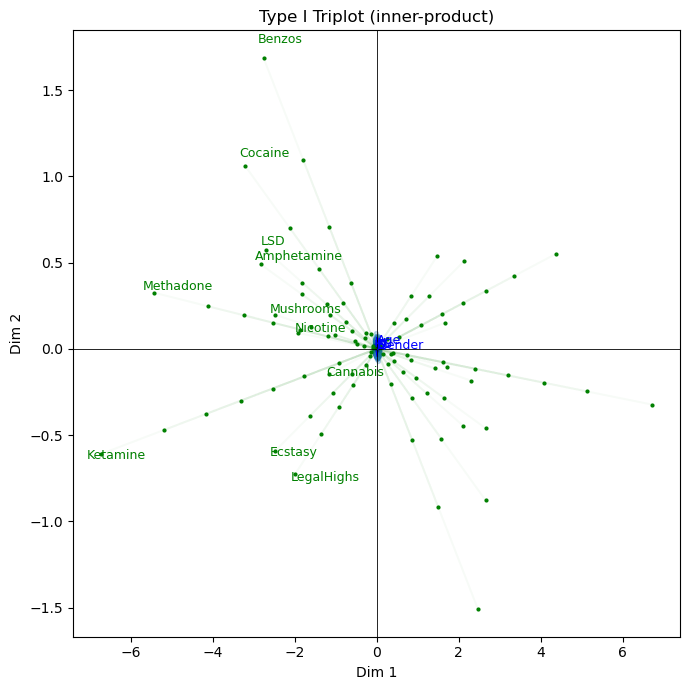


Plot: Type D triplot


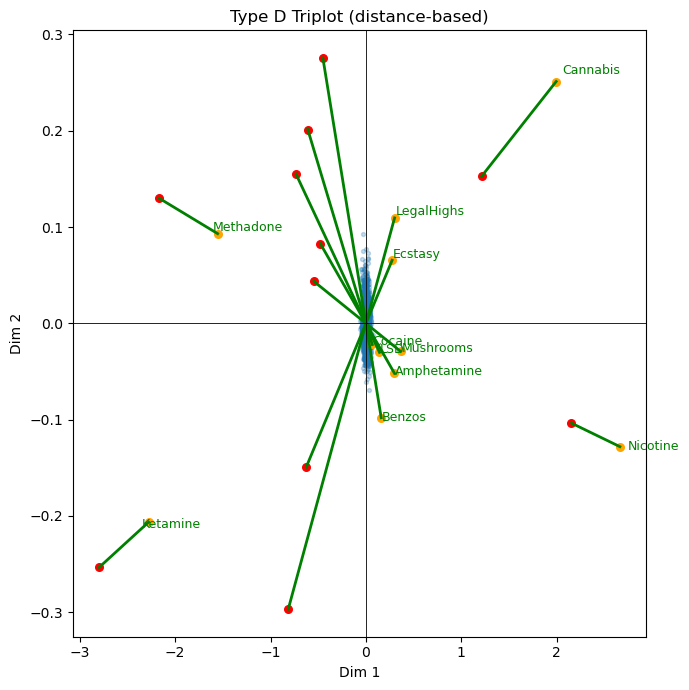


Plot: Hybrid triplot


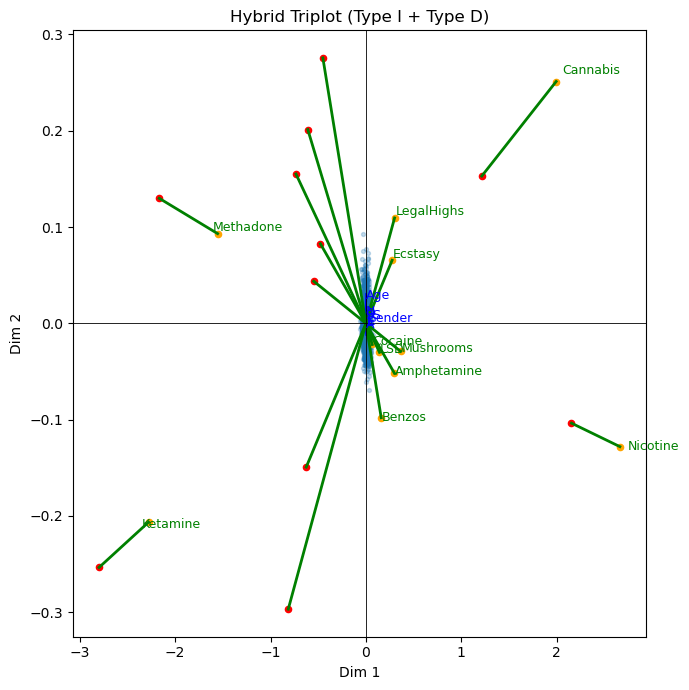

In [10]:
#  Qr (quality-of-representation)
B_mm = results["mm"]["B"]
V_mm = results["mm"]["V"]
m_mm = results["mm"]["m"]

print("Computing Qr for MM solution: ")
Qr_vals = compute_Qr_for_mm(X, Y, B_mm, V_mm, m_mm)
for i, q in enumerate(Qr_vals):
    name = response_names[i] if response_names is not None else f"Y{i}"
    print(f"  Qr[{name}] = {q:.4f}")
print("Average Qr:", np.mean(Qr_vals))

# Type I triplot
print("\nPlot: Type I triplot")
plot_type1_triplot(X, B_mm, V_mm, m_mm, predictor_names=predictor_names, response_names=response_names)

# Type D triplot
print("\nPlot: Type D triplot")
plot_typeD_triplot(X, B_mm, V_mm, m_mm, response_names=response_names)

# Hybrid triplot
print("\nPlot: Hybrid triplot")
plot_hybrid_triplot(X, B_mm, V_mm, m_mm, predictor_names=predictor_names, response_names=response_names)


# PLOT SUMMARIES

## For STUDENT Dataset

## 1. Type I Triplot (Inner-Product Representation)

The Type I triplot visualizes the logistic reduced-rank regression model using inner-product geometry, similar to a logistic PCA biplot. It shows how predictor directions and response variables interact in the latent space.

### A. Response variable axes (green)

Each binary response (e.g., pass_math, pass_por, high_absence) is shown as a directional axis radiating from the origin. Movement along the axis increases the predicted probability of the corresponding “YES” outcome.

The length of the axis reflects how strongly the response is influenced by the underlying latent dimensions.

The direction shows how the outcome aligns with the latent factors.

### B. Angular interpretation

The angle between response axes indicates how related the outcomes are:

Small angle = outcomes behave similarly (positively associated).

~180° angle = outcomes behave oppositely (negative association).

~90° angle = outcomes are independent in the latent space.

In this plot:

pass_math and pass_por point in nearly opposite directions → students doing well in one tend to be weak in the other in this latent structure.

high_absence forms large angles with both pass variables → absences are relatively independent of academic performance.

### C. Student positions (blue points)

Students are projected into the 2D latent space:

Points near origin → moderate/average predicted probabilities.

Points far along a response axis → high probability for that outcome.

Points in opposite direction → low probability.

This plot is ideal for understanding predictor–response relationships, outcome similarities, and directions of increasing probability, but does not show explicit YES/NO category points.

## 2. Type D Triplot (Distance-Based Representation)

The Type D triplot represents each binary response using two category points—one for “NO” and one for “YES”. The model geometry is entirely distance-based.

### A. YES and NO category points

For each outcome:

Orange point = NO category (e.g., fail_math)

Red point = YES category (e.g., pass_math)

The distance between these two points represents the model’s ability to discriminate between categories:

Large separation → predictors strongly differentiate YES from NO.

Small separation → response is poorly predicted.

In this plot:

pass_math shows the largest gap → strong discrimination.

pass_por is well separated → good predictive power.

high_absence YES/NO points are close → weakly predicted.

### B. Student probabilities

A student’s predicted probability depends on which endpoint they are closer to:

Closer to YES → high probability of positive outcome.

Closer to NO → low probability.

Near midpoint → ~50% predicted probability.

This makes classification visually intuitive.

### C. Relative positioning

Because each response has its own YES/NO pair,

You can see how the latent space organizes students with respect to all binary outcomes simultaneously.

Distances rather than projections determine probabilities.

This plot is best for interpreting classification boundaries, visualizing category separation, and understanding discriminative strength, but does not show predictor directions directly.

## 3. Hybrid Triplot (Type I + Type D Combined)

The Hybrid triplot merges the interpretability strengths of both Type I and Type D. It keeps the directional axes from Type I and adds the YES/NO endpoints from Type D.

### A. Response axes with two endpoints

Each outcome axis has:

Orange (NO) and Red (YES) endpoints placed on the axis itself.

These endpoints come from the Type D representation but are constrained to lie along the Type I direction.

This gives:

The direction of increasing probability (Type I),

The strength of discrimination (Type D),

Explicit category separation on the same axis.

Longer axis segment = stronger prediction signal
Shorter axis segment = weaker prediction

### B. Student positions

Student points behave as in Type I:

Projection onto the response axis gives predicted probability.

But now, you can also see the YES and NO categories visually.

Thus, prediction can be interpreted using either:

Projection (inner-product logic), or

Distance to YES/NO endpoints (classification logic).

### C. Interpretation across outcomes

In this hybrid plot:

pass_math axis shows a long segment between NO → YES → strongest predictor-based discrimination.

pass_por axis also shows clear separation.

high_absence axis displays a shorter segment → weakly predicted outcome.

This hybrid representation is the most informative because it shows:

Predictor relationships

Outcome directions

Category positions

Discrimination strength

Student probabilities (projection or distance)

All in a single unified plot.

## For DRUG Dataset

### 1. Type I Triplot (Inner-Product Representation)

The Type I triplot visualizes the logistic reduced rank regression model using an inner-product geometry.
Responses (drug variables), predictors, and individuals are displayed in a shared latent space.

• Response variable axes

Each drug is represented as a green axis emanating from the origin.

Movement along the axis corresponds to an increase in predicted probability of using that drug.

The length of each axis reflects how strongly the latent dimensions discriminate that specific drug outcome.

• Angular relationships among drug outcomes

Small angles between axes indicate similar patterns of drug use.

Large opposing angles represent contrasting usage tendencies.

Near-orthogonal axes reflect weak or minimal association.

Drugs with similar directions share underlying behavioral patterns captured by the latent components.

• Position of respondents

Respondents are clustered in the latent space based on similarity in predicted drug-use probabilities.

Those located near a drug axis exhibit higher predicted probability for that drug.

Those positioned opposite the axis exhibit lower predicted probability.

Dense clustering near the origin reflects moderate or average probabilities across most drugs.

• Interpretive emphasis

Highlights relationships among drug variables.

Provides directional insight into how latent components influence each drug.

Allows probability interpretation through projection onto axes.

Captures underlying multivariate structure in a form analogous to logistic PCA.

### 2. Type D Triplot (Distance-Based Representation)

The Type D triplot represents the logistic reduced rank regression model using a distance-based geometry.
Each binary outcome is depicted using two category points corresponding to “YES” and “NO.”

• YES and NO category points

Every drug variable is represented by two endpoints:

Yellow/orange point → Non-use (NO) category

Red point → Use (YES) category

These points form a segment along the latent dimensions indicating how respondents are separated based on drug use.

• Discriminatory strength

The distance between YES and NO points measures how well the model separates users from non-users.

Longer distances indicate strong discriminative ability for that drug.

Shorter distances indicate weak separation and limited predictive power.

• Respondent locations

Respondents appear as points scattered around the category structures.

Distance to YES and NO points determines the relative likelihood of drug use.

Respondents closer to the YES endpoint have higher predicted probabilities; those closer to the NO endpoint have lower probabilities.

• Interpretive emphasis

Highlights classification behavior of the model.

Emphasizes separation of drug-use categories rather than directional relationships.

Useful for evaluating which drugs are easiest or hardest to predict.

Provides a geometric understanding of binary class distinctions for each drug.

### 3. Hybrid Triplot (Type I + Type D Combined)

The Hybrid triplot merges the informative aspects of both the Type I and Type D representations.
It superimposes category endpoints onto the inner-product axes, yielding a unified, more interpretable display.

• Combined response axes

Each drug retains its directional axis (from the Type I representation), showing how predicted probabilities change along the axis.

The axis now includes both YES and NO endpoints, placed according to the Type D geometry.

• YES/NO separation on the axis

The segment connecting the NO and YES category points reflects the drug’s discriminative strength.

Longer and more separated segments imply strong predictor influence.

Short segments signify weaker prediction and limited latent separation.

• Respondent placement

Respondents appear as points within the same coordinate system as the axes and category points.

Individuals closer to the YES endpoint have higher predicted probabilities; closer to the NO endpoint implies lower probabilities.

Placement relative to the axis also conveys projected probability through inner-product geometry.

• Interpretive emphasis

Provides both directional interpretation (from Type I) and classification clarity (from Type D).

Facilitates analysis of:

predictor influence,

response–response relationships,

the magnitude and direction of probability gradients,

category separation across drugs.

Offers the most complete and integrated insight into the multivariate structure of drug-use behavior.

In [11]:
# ============================
# Enhanced triplot utilities (styling + decision lines)
# Paste after your model fit (B_mm, V_mm, m_mm available)
# ============================
import matplotlib.pyplot as plt
import numpy as np

def _plot_base(scores_plot, title, figsize, scatter_alpha, scatter_s):
    plt.figure(figsize=figsize)
    plt.scatter(scores_plot[:,0], scores_plot[:,1],
                c='lightgray', edgecolor='none', alpha=scatter_alpha, s=scatter_s, label='objects')
    plt.axhline(0, color='black', linewidth=0.6, alpha=0.6)
    plt.axvline(0, color='black', linewidth=0.6, alpha=0.6)
    plt.title(title, fontsize=14)
    plt.xlabel("Dimension 1", fontsize=12)
    plt.ylabel("Dimension 2", fontsize=12)

def _perp_vector(v):
    """Return a perpendicular vector to v (2-d)."""
    return np.array([-v[1], v[0]])

def _span_for_lines(scores):
    """Estimate a plotting span to draw decision lines that extend beyond cloud."""
    # use the range of the scores
    sx = np.ptp(scores[:,0]) if scores.shape[0] > 1 else 1.0
    sy = np.ptp(scores[:,1]) if scores.shape[0] > 1 else 1.0
    span = max(sx, sy)
    if span == 0:
        span = 1.0
    return span * 1.8

# -----------------------------
# Enhanced Type I with decision lines
# -----------------------------
def plot_type1_triplot_styled(X, B, V, m,
                              predictor_names=None, response_names=None,
                              max_predictors=12, subsample=1200,
                              figsize=(7,7),
                              scatter_alpha=0.25, scatter_s=10,
                              pred_color='tab:blue', resp_color='tab:green',
                              decision_color='tab:red', fontsize=10):
    """
    Type I with styling & decision lines.
    Decision line per response is perpendicular to response axis through 0.5-marker.
    """
    S = B.shape[1]
    scores = X @ B
    N = scores.shape[0]
    # subsample for plotting clarity
    if N > subsample:
        idx = np.linspace(0, N-1, subsample).astype(int)
        scores_plot = scores[idx]
    else:
        scores_plot = scores

    _plot_base(scores_plot, "Type I Triplot (styled + decision lines)", figsize, scatter_alpha, scatter_s)

    # predictor axes (top-k by norm)
    pred_norms = np.linalg.norm(B, axis=1)
    top_idx = np.argsort(pred_norms)[::-1][:max_predictors]
    for j in top_idx:
        vec = B[j,:S]
        plt.arrow(0,0, vec[0], vec[1], color=pred_color, width=0.002, head_width=0.03, length_includes_head=True)
        name = predictor_names[j] if predictor_names is not None else f"X{j}"
        plt.text(vec[0]*1.12, vec[1]*1.12, name, color=pred_color, fontsize=fontsize)

    # responses: plot axis and probability markers + decision line
    R = V.shape[0]
    span = _span_for_lines(scores)
    probs = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
    for r in range(R):
        vr = V[r]             # (S,)
        denom = (vr @ vr)
        if denom < 1e-12:
            continue

        # Prob markers (small green dots along axis)
        for p in probs:
            lam = np.log(p/(1-p)) - m[r]   # lambda = logit(p) - m_r
            pos = (lam / denom) * vr
            plt.scatter(pos[0], pos[1], s=6, color=resp_color, alpha=0.6)

        # label at 0.9 marker
        lam9 = np.log(0.9/0.1) - m[r]
        pos9 = (lam9 / denom) * vr
        lbl = response_names[r] if response_names is not None else f"Y{r}"
        plt.text(pos9[0]*1.06, pos9[1]*1.06, lbl, color=resp_color, fontsize=fontsize)

        # Decision line: perpendicular to vr, through 0.5-marker
        lam50 = np.log(0.5/0.5) - m[r]   # = -m[r]
        mid = (lam50 / denom) * vr       # midpoint location for p=0.5
        perp = _perp_vector(vr)
        perp_unit = perp / np.linalg.norm(perp)
        line_pts = np.vstack([mid - perp_unit * span, mid + perp_unit * span])
        plt.plot(line_pts[:,0], line_pts[:,1], color=decision_color, linestyle='--', linewidth=1.2, alpha=0.9)

    plt.tight_layout()
    plt.show()


# -----------------------------
# Enhanced Type D with decision lines
# -----------------------------
def plot_typeD_triplot_styled(X, B, V, m,
                              response_names=None, subsample=1200,
                              figsize=(7,7),
                              scatter_alpha=0.25, scatter_s=10,
                              cat0_color='red', cat1_color='orange',
                              line_color='tab:green', decision_color='tab:red',
                              fontsize=10):
    """
    Type D styled: plot objects and category points (wr0, wr1) and decision line perpendicular to (wr1 - wr0) through midpoint.
    """
    scores = X @ B
    N = scores.shape[0]
    if N > subsample:
        idx = np.linspace(0, N-1, subsample).astype(int)
        scores_plot = scores[idx]
    else:
        scores_plot = scores

    _plot_base(scores_plot, "Type D Triplot (styled + decision lines)", figsize, scatter_alpha, scatter_s)

    # compute K and L per paper: K = -V/2 ; l_rs = m_r * k_rs / (2 * sum k_rs^2)
    K = -V / 2.0
    R, S = K.shape
    L = np.zeros_like(K)
    for r in range(R):
        denom = np.sum(K[r]**2)
        if denom < 1e-12:
            L[r,:] = 0.0
        else:
            L[r,:] = (m[r] * K[r]) / (2.0 * denom)

    W0 = L - K   # (R×S)
    W1 = L + K   # (R×S)

    # span for drawing decision lines
    span = _span_for_lines(scores)

    for r in range(R):
        # plot connecting segment
        plt.plot([W0[r,0], W1[r,0]], [W0[r,1], W1[r,1]], color=line_color, linewidth=2)
        plt.scatter(W0[r,0], W0[r,1], color=cat0_color, s=45, zorder=5)
        plt.scatter(W1[r,0], W1[r,1], color=cat1_color, s=45, zorder=5)
        lbl = response_names[r] if response_names is not None else f"Y{r}"
        plt.text(W1[r,0]*1.04, W1[r,1]*1.04, lbl, color=line_color, fontsize=fontsize)

        # decision line: perpendicular to (W1-W0) through midpoint
        vec = W1[r] - W0[r]
        if np.linalg.norm(vec) < 1e-12:
            continue
        perp = _perp_vector(vec)
        perp_unit = perp / np.linalg.norm(perp)
        mid = 0.5 * (W0[r] + W1[r])
        line_pts = np.vstack([mid - perp_unit * span, mid + perp_unit * span])
        plt.plot(line_pts[:,0], line_pts[:,1], color=decision_color, linestyle='--', linewidth=1.2, alpha=0.9)

    plt.tight_layout()
    plt.show()


# -----------------------------
# Enhanced Hybrid plot (Type I axes + Type D solid segment + decision lines)
# -----------------------------
def plot_hybrid_triplot_styled(X, B, V, m,
                               predictor_names=None, response_names=None,
                               max_predictors=12, subsample=1200,
                               figsize=(7,7),
                               scatter_alpha=0.25, scatter_s=10,
                               pred_color='tab:blue', resp_color='tab:green',
                               cat0_color='red', cat1_color='orange',
                               decision_color='tab:red', fontsize=10):
    """
    Hybrid: predictor axes + solid response segment between category points; includes decision lines.
    """
    S = B.shape[1]
    scores = X @ B
    N = scores.shape[0]
    if N > subsample:
        idx = np.linspace(0, N-1, subsample).astype(int)
        scores_plot = scores[idx]
    else:
        scores_plot = scores

    _plot_base(scores_plot, "Hybrid Triplot (styled + decision lines)", figsize, scatter_alpha, scatter_s)

    # predictor axes (top-k)
    pred_norms = np.linalg.norm(B, axis=1)
    top_idx = np.argsort(pred_norms)[::-1][:max_predictors]
    for j in top_idx:
        vec = B[j,:S]
        plt.arrow(0,0, vec[0], vec[1], color=pred_color, width=0.002, head_width=0.03)
        name = predictor_names[j] if predictor_names is not None else f"X{j}"
        plt.text(vec[0]*1.12, vec[1]*1.12, name, color=pred_color, fontsize=fontsize)

    # compute K, L and category endpoints
    K = -V / 2.0
    R = V.shape[0]
    L = np.zeros_like(K)
    for r in range(R):
        denom = np.sum(K[r]**2)
        if denom < 1e-12:
            L[r,:] = 0.0
        else:
            L[r,:] = (m[r] * K[r]) / (2.0 * denom)
    W0 = L - K
    W1 = L + K

    span = _span_for_lines(scores)

    for r in range(R):
        # solid segment between category points
        plt.plot([W0[r,0], W1[r,0]], [W0[r,1], W1[r,1]], color=resp_color, linewidth=2)
        plt.scatter(W0[r,0], W0[r,1], color=cat0_color, s=30)
        plt.scatter(W1[r,0], W1[r,1], color=cat1_color, s=30)
        lbl = response_names[r] if response_names is not None else f"Y{r}"
        plt.text(W1[r,0]*1.04, W1[r,1]*1.04, lbl, color=resp_color, fontsize=fontsize)

        # decision line perpendicular to segment through midpoint
        vec = W1[r] - W0[r]
        if np.linalg.norm(vec) < 1e-12:
            continue
        perp = _perp_vector(vec)
        perp_unit = perp / np.linalg.norm(perp)
        mid = 0.5 * (W0[r] + W1[r])
        line_pts = np.vstack([mid - perp_unit * span, mid + perp_unit * span])
        plt.plot(line_pts[:,0], line_pts[:,1], color=decision_color, linestyle='--', linewidth=1.1, alpha=0.9)

    plt.tight_layout()
    plt.show()


Qr (MM):
   Amphetamine : Qr = 0.0415
        Benzos : Qr = 0.0392
      Cannabis : Qr = 0.0276
       Cocaine : Qr = 0.0405
       Ecstasy : Qr = 0.0400
      Ketamine : Qr = 0.0272
    LegalHighs : Qr = 0.0368
           LSD : Qr = 0.0376
     Methadone : Qr = 0.0285
     Mushrooms : Qr = 0.0397
      Nicotine : Qr = 0.0302
Average Qr: 0.035342172016055974


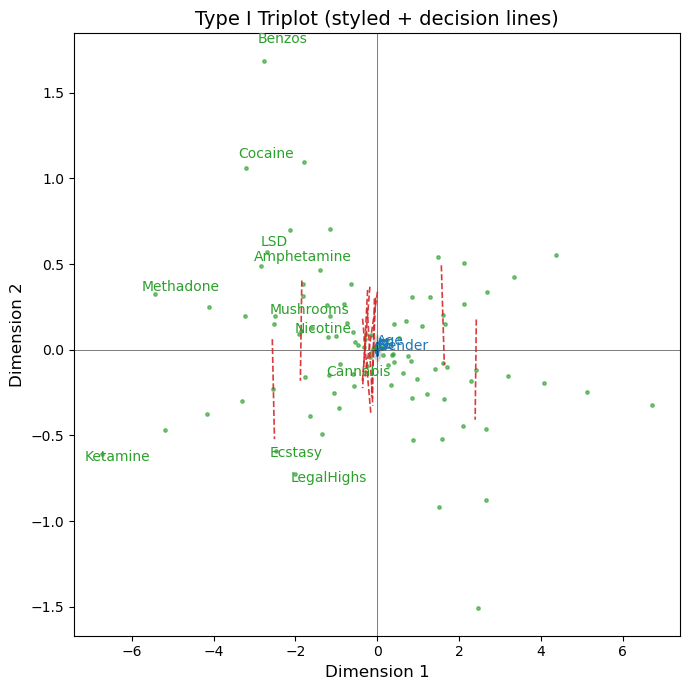

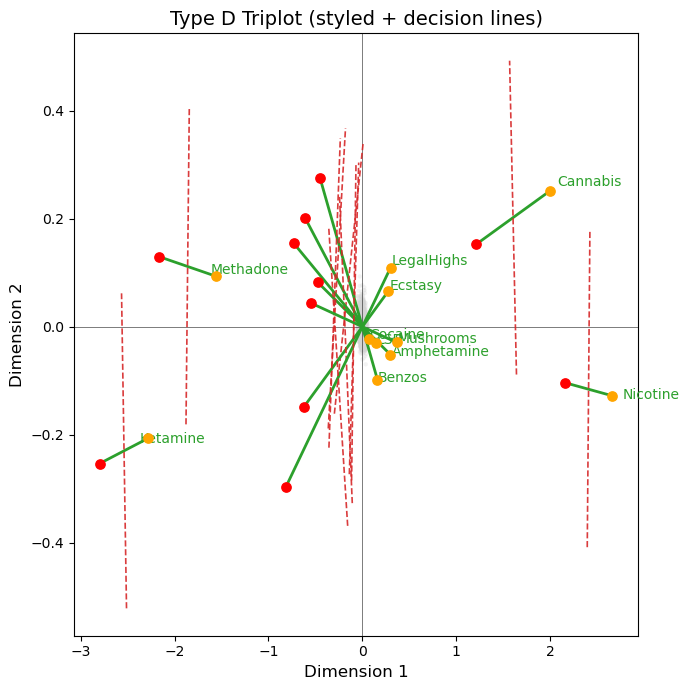

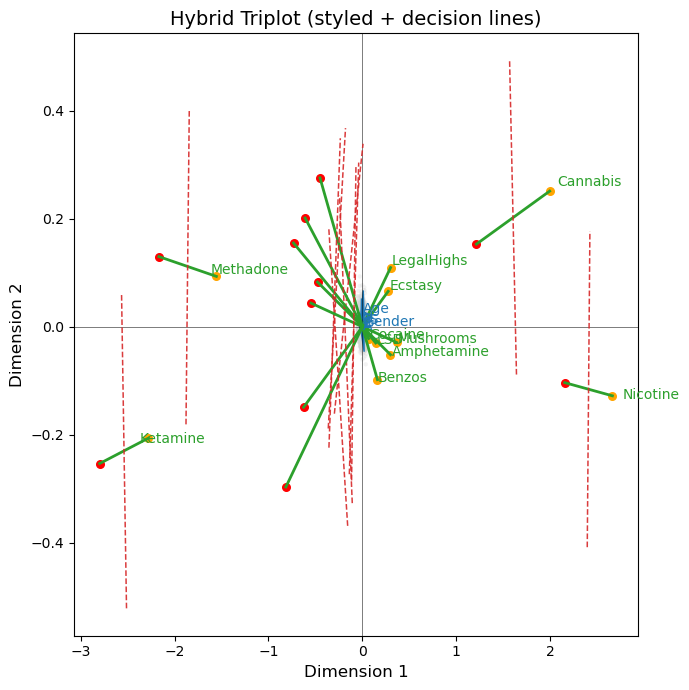

In [12]:
# ============================
# Example usage: compute Qr + show enhanced triplots
# Assumes: X, Y, predictor_names, response_names, results exist
# ============================
# 1) Qr (re-using your compute_Qr_for_mm from previous cell A)
B_mm = results["mm"]["B"]
V_mm = results["mm"]["V"]
m_mm = results["mm"]["m"]

print("Qr (MM):")
Qr_vals = compute_Qr_for_mm(X, Y, B_mm, V_mm, m_mm)
for r, q in enumerate(Qr_vals):
    print(f"  {response_names[r]:>12s} : Qr = {q:.4f}")
print("Average Qr:", np.mean(Qr_vals))

# 2) Plots
plot_type1_triplot_styled(X, B_mm, V_mm, m_mm,
                          predictor_names=predictor_names,
                          response_names=response_names,
                          max_predictors=10)

plot_typeD_triplot_styled(X, B_mm, V_mm, m_mm,
                          response_names=response_names)

plot_hybrid_triplot_styled(X, B_mm, V_mm, m_mm,
                           predictor_names=predictor_names,
                           response_names=response_names,
                           max_predictors=10)
